<a href="https://colab.research.google.com/github/EdwinZhanCN/Lab-2/blob/main/03_rnn_and_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Datasheet

This lab is using UCI Human Activity Recognition, https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones. It is aimed to established a Human Acitivity Recognition System on edge devices like smartphones. We're using it to predict human acitivities via neural networks.

### Sanity check

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip -q -o "UCI HAR Dataset.zip"

DATA_DIR = 'UCI HAR Dataset'

def load_inertial_signals(subset='train'):
    signal_dir = os.path.join(DATA_DIR, subset, 'Inertial Signals')

    filenames = [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z'
    ]

    signals = []
    for name in filenames:
        filepath = os.path.join(signal_dir, f"{name}_{subset}.txt")
        channel_data = np.loadtxt(filepath)
        signals.append(channel_data)

    X = np.dstack(signals)

    y_path = os.path.join(DATA_DIR, subset, f"y_{subset}.txt")
    y = np.loadtxt(y_path, dtype=int) - 1

    sub_path = os.path.join(DATA_DIR, subset, f"subject_{subset}.txt")
    subjects = np.loadtxt(sub_path, dtype=int)

    return X, y, subjects

X_train_raw, y_train_raw, subjects_train = load_inertial_signals('train')
X_test, y_test, subjects_test = load_inertial_signals('test')

def perform_sanity_checks(X, y, dataset_name="Train"):
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    has_nan = np.isnan(X).any()
    has_inf = np.isinf(X).any()
    print(f"NaN? {has_nan}")
    print(f"Inf? {has_inf}")

    activity_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']
    label_counts = pd.Series(y).value_counts().sort_index()

    for label, count in label_counts.items():
        print(f"Class {label} ({activity_names[label]}): {count} windows")
    print("\n")

perform_sanity_checks(X_train_raw, y_train_raw, "Train")
perform_sanity_checks(X_test, y_test, "Test")

X shape: (7352, 128, 9)
y shape: (7352,)
NaN? False
Inf? False
Class 0 (Walking): 1226 windows
Class 1 (Walking Upstairs): 1073 windows
Class 2 (Walking Downstairs): 986 windows
Class 3 (Sitting): 1286 windows
Class 4 (Standing): 1374 windows
Class 5 (Laying): 1407 windows


X shape: (2947, 128, 9)
y shape: (2947,)
NaN? False
Inf? False
Class 0 (Walking): 496 windows
Class 1 (Walking Upstairs): 471 windows
Class 2 (Walking Downstairs): 420 windows
Class 3 (Sitting): 491 windows
Class 4 (Standing): 532 windows
Class 5 (Laying): 537 windows




## Leakage Audit

In [20]:
import numpy as np

def create_subject_disjoint_split(X, y, subjects, val_ratio=0.2, seed=42):
    np.random.seed(seed)
    unique_subjects = np.unique(subjects)
    print(f"Total: {len(unique_subjects)} -> {unique_subjects}")
    np.random.shuffle(unique_subjects)
    num_val_subjects = int(len(unique_subjects) * val_ratio)

    val_subjects = unique_subjects[:num_val_subjects]
    train_subjects = unique_subjects[num_val_subjects:]

    train_mask = np.isin(subjects, train_subjects)
    val_mask = np.isin(subjects, val_subjects)
    X_train, y_train, sub_train = X[train_mask], y[train_mask], subjects[train_mask]
    X_val, y_val, sub_val = X[val_mask], y[val_mask], subjects[val_mask]
    train_sub_set = set(sub_train)
    val_sub_set = set(sub_val)
    intersection = train_sub_set.intersection(val_sub_set)

    print(f"Train set: {train_sub_set}")
    print(f"Val set: {val_sub_set}")
    print(f"Intersection: {len(intersection)}")

    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")

    return X_train, y_train, X_val, y_val

X_train, y_train, X_val, y_val = create_subject_disjoint_split(X_train_raw, y_train_raw, subjects_train)

Total: 21 -> [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Train set: {np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(28), np.int64(29), np.int64(30)}
Val set: {np.int64(27), np.int64(1), np.int64(3), np.int64(25)}
Intersection: 0
X_train: (5879, 128, 9), y_train: (5879,)
X_val: (1473, 128, 9), y_val: (1473,)


## Baseline 0:

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train, y_train)

y_val_pred_dummy = dummy_clf.predict(X_val)

dummy_acc = accuracy_score(y_val, y_val_pred_dummy)
dummy_f1 = f1_score(y_val, y_val_pred_dummy, average='macro')

print(f"Baseline 0, Validation Accuracy: {dummy_acc:.4f}")
print(f"Baseline 0, Validation Macro-F1: {dummy_f1:.4f}")

Baseline 0, Validation Accuracy: 0.1758
Baseline 0, Validation Macro-F1: 0.0498


Baseline 0 serves as a reference model. It utilizes a majority-class prediction strategy with a fixed random seed, it simply outputs the most frequent class found in the training data for every prediction. It achieved a validation accuracy of 0.1758 and a macro-F1 score of 0.0498. Any effective deep learning model must significantly outperform these metrics to demonstrate true learning.

## Baseline 1:

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(42)

# Convert to toch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Load the data
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

class MLPBaseline(nn.Module):
    def __init__(self, input_size=128*9, num_classes=6):
        super(MLPBaseline, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPBaseline().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
print(f"Training on device: {device}")

train_losses = []
val_losses = []
val_f1s = []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    val_losses.append(val_loss)
    val_f1s.append(val_f1)

    print(f"Epoch [{epoch+1}/{epochs}]Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

Training on device: cuda
Epoch [1/10]Train Loss: 0.6710 | Val Loss: 0.2698 | Val F1: 0.8915
Epoch [2/10]Train Loss: 0.2295 | Val Loss: 0.1606 | Val F1: 0.9432
Epoch [3/10]Train Loss: 0.1473 | Val Loss: 0.1539 | Val F1: 0.9424
Epoch [4/10]Train Loss: 0.1314 | Val Loss: 0.2135 | Val F1: 0.9446
Epoch [5/10]Train Loss: 0.1197 | Val Loss: 0.1062 | Val F1: 0.9713
Epoch [6/10]Train Loss: 0.1097 | Val Loss: 0.1775 | Val F1: 0.9480
Epoch [7/10]Train Loss: 0.1005 | Val Loss: 0.1247 | Val F1: 0.9589
Epoch [8/10]Train Loss: 0.1007 | Val Loss: 0.2168 | Val F1: 0.9529
Epoch [9/10]Train Loss: 0.1023 | Val Loss: 0.2725 | Val F1: 0.9429
Epoch [10/10]Train Loss: 0.1162 | Val Loss: 0.2141 | Val F1: 0.9535


### Plot

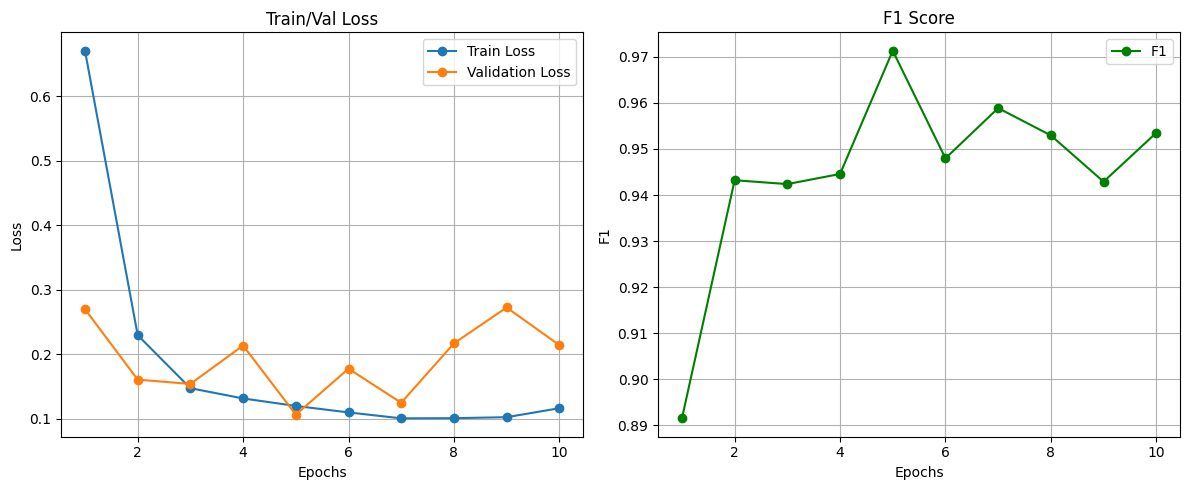

In [23]:
import matplotlib.pyplot as plt

epoch_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_range, train_losses, label='Train Loss', marker='o')
plt.plot(epoch_range, val_losses, label='Validation Loss', marker='o')
plt.title('Train/Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epoch_range, val_f1s, label='F1', color='green', marker='o')
plt.title('F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation

MLP Baseline - Validation Accuracy: 0.9532
MLP Baseline - Validation Macro-F1: 0.9535
              precision    recall  f1-score   support

     Walking       0.97      0.95      0.96       284
  Walking Up       0.99      0.96      0.98       228
Walking Down       0.97      0.95      0.96       200
     Sitting       0.84      1.00      0.91       234
    Standing       0.97      0.86      0.91       268
      Laying       1.00      1.00      1.00       259

    accuracy                           0.95      1473
   macro avg       0.96      0.95      0.95      1473
weighted avg       0.96      0.95      0.95      1473



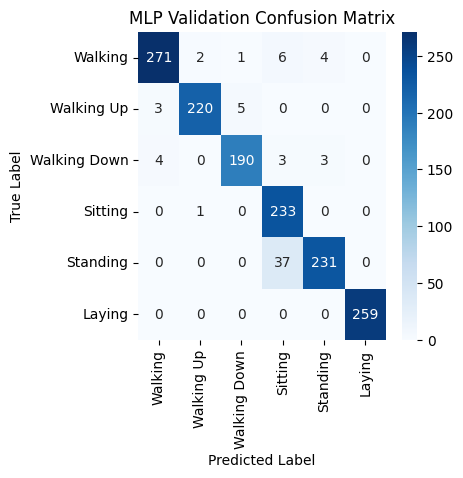

In [24]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

mlp_acc = accuracy_score(all_labels, all_preds)
mlp_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"MLP Baseline - Validation Accuracy: {mlp_acc:.4f}")
print(f"MLP Baseline - Validation Macro-F1: {mlp_f1:.4f}")

activity_names = ['Walking', 'Walking Up', 'Walking Down', 'Sitting', 'Standing', 'Laying']

print(classification_report(all_labels, all_preds, target_names=activity_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_names, yticklabels=activity_names)
plt.title('MLP Validation Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Baseline 1 implements a MLP trained on flattened sensor windows. The model achieved a validation accuracy of 94.43% and a macro-F1 score of 0.9448, outperforming the Baseline 0.

The per-class metrics  reveal that the model perfectly identifies the "Laying" class (F1-score: 1.00) and performs exceptionally well on class like "Walking" and "Walking Up."

However, it is difficult to distinguish "Sitting" (lower precision at 0.84, but perfect recall) at the expense of "Standing" (lower recall at 0.86).

Looking at the confusion matrix above, it has perfect recognition of the "Laying" class, with the primary error being the misclassification of 37 "Standing" instances as "Sitting".

### Task 8: Overfitting Control

#### Experiment method

In [25]:
def run_experiment(model, optimizer, criterion, epochs):
    best_f1 = 0.0
    train_losses = []
    val_losses = []
    val_f1s = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        val_f1s.append(val_f1)
        if val_f1 > best_f1:
            best_f1 = val_f1

    epoch_range = range(1, epochs + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epoch_range, train_losses, label='Train Loss', marker='o')
    plt.plot(epoch_range, val_losses, label='Validation Loss', marker='o')
    plt.title('Train/Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epoch_range, val_f1s, label='F1', color='green', marker='o')
    plt.title('F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return best_f1

#### Induce Overfitting

Let the MLP be oversized,

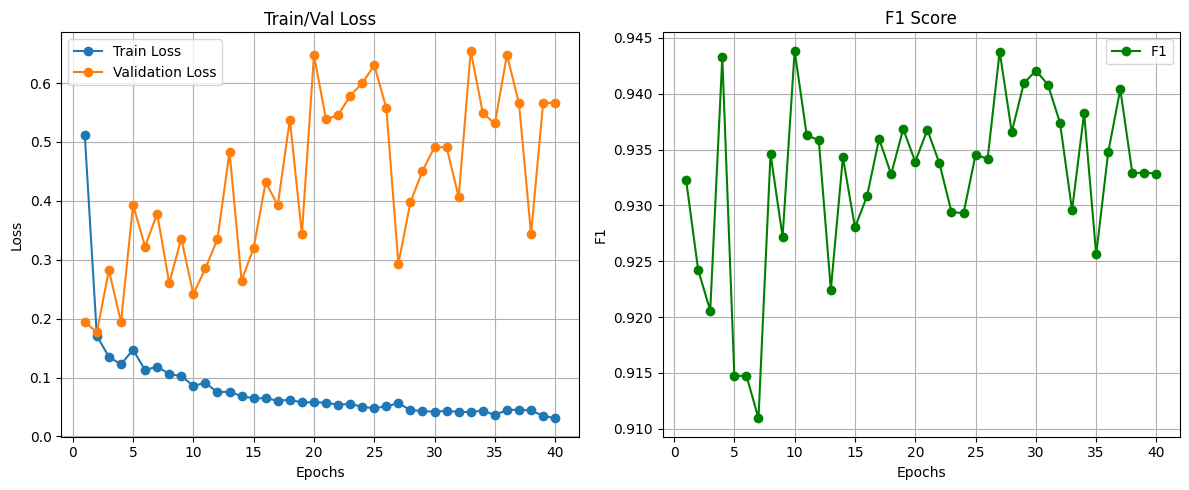

OversizedMLP F1 Scroe:  0.9438


In [26]:
# Set constants
learning_rate = 0.001 # Normal learning rate against task 9
criterion = nn.CrossEntropyLoss()

class OversizedMLP(nn.Module):
    def __init__(self, input_size=128*9, num_classes=6):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, num_classes)
        )
    def forward(self, x):
        return self.network(self.flatten(x))

model_overfit = OversizedMLP().to(device)
optimizer_overfit = optim.Adam(model_overfit.parameters(), lr=learning_rate)
f1_overfit = run_experiment(model_overfit, optimizer_overfit, criterion, epochs=40)
print(f"OversizedMLP F1 Scroe: {f1_overfit: .4f}")

#### Fix overfitting

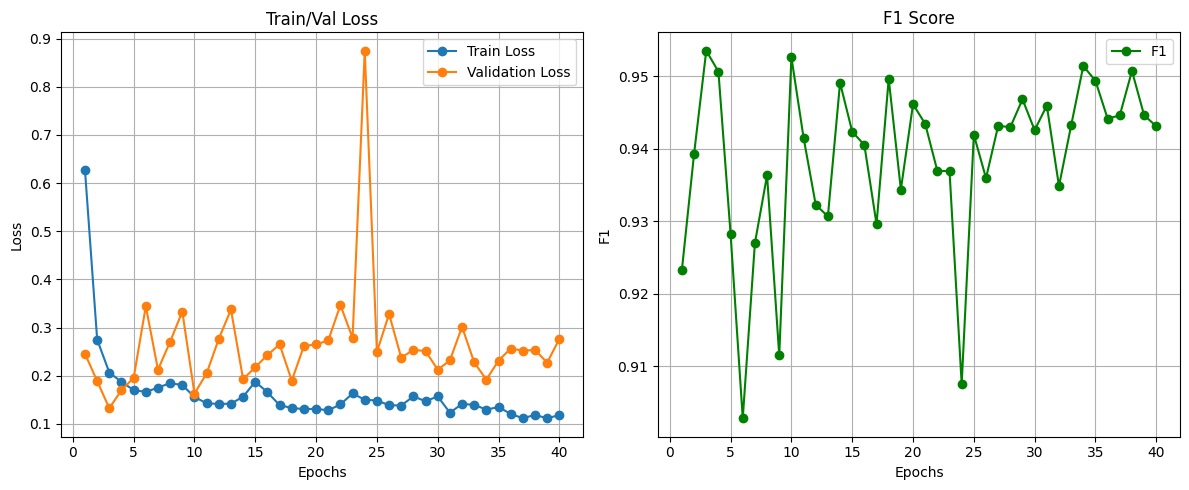

RegularizedMLP F1 Score:  0.9535


In [27]:
class RegularizedMLP(nn.Module):
    def __init__(self, input_size=128*9, num_classes=6):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 2048), # 512 -> 2048
            nn.Dropout(), # introduce dropout
            nn.ReLU(),
            nn.Linear(2048, 1024), # 128 -> 1024
            nn.Dropout(),
            nn.ReLU(),
            nn.Linear(1024, num_classes)
        )
    def forward(self, x):
        return self.network(self.flatten(x))

model_reg = RegularizedMLP().to(device)
# Adding weight_decay
optimizer_reg = optim.Adam(model_reg.parameters(), lr=learning_rate, weight_decay=1e-4)

f1_reg = run_experiment(model_reg, optimizer_reg, criterion, epochs=40)
print(f"RegularizedMLP F1 Score: {f1_reg: .4f}")

### Task 9: Instability debug

In [28]:
import math
# Renewed version for experiment running, log the NaN:
def run_experiment_task9(model, optimizer, criterion, epochs):
    best_f1 = 0.0

    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')
        if val_f1 > best_f1:
            best_f1 = val_f1

        if math.isnan(loss.item()):
            print(f"Loss is NaN, process aborted.")
            return

    return best_f1

In [29]:
instable_lr = 1e-6
instable_model = MLPBaseline().to(device)
instable_optim = optim.Adam(instable_model.parameters(), lr=instable_lr, weight_decay=0.5)
f1_instable = run_experiment_task9(instable_model, instable_optim, criterion, epochs=35)
print(f"InstableMLP F1 Score: {f1_instable: .4f}")

InstableMLP F1 Score:  0.2207


#### Fixed optimizer

In [30]:
stable_model= MLPBaseline().to(device)

stable_optim = optim.Adam(stable_model.parameters(), lr=0.001, weight_decay=0.0)

f1_stable = run_experiment_task9(stable_model, stable_optim, criterion, epochs=35)
print(f"StableMLP F1 Score: {f1_stable:.4f}")

StableMLP F1 Score: 0.9566


### Task 11

RNN Implementation: LSTM and GRU.

In [32]:
class RNN(nn.Module):
    def __init__(self, input_size=9, hidden_size=64, num_layers=1, num_classes=6, dropout_p=0.5):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)

        last_out = out[:, -1, :]

        last_out = self.dropout(last_out)
        logits = self.fc(last_out)
        return logits

model_rnn = RNN().to(device)

### Task 12


Training

In [36]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_rnn.parameters(), lr=0.005, weight_decay=1e-4) # Add weight decay

# 1: decreasing learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

epochs = 10
best_f1 = 0.0

print(f"==== Training ====")

for epoch in range(epochs):
    model_rnn.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_rnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        # 2. grad clipping
        nn.utils.clip_grad_norm_(model_rnn.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)

    # eval
    model_rnn.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_rnn(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_f1 = f1_score(all_labels, all_preds, average='macro')

    # val_loss for scheduler
    scheduler.step(val_loss)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_rnn.state_dict(), 'best_rnn_model.pth')

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

print(f"Best Val F1: {best_f1:.4f}")

==== Training ====
Epoch [1/10] - Train Loss: 0.1521 | Val Loss: 0.1921 | Val F1: 0.9462
Epoch [2/10] - Train Loss: 0.1547 | Val Loss: 0.1138 | Val F1: 0.9670
Epoch [3/10] - Train Loss: 0.1517 | Val Loss: 0.0528 | Val F1: 0.9920
Epoch [4/10] - Train Loss: 0.1498 | Val Loss: 0.1038 | Val F1: 0.9747
Epoch [5/10] - Train Loss: 0.1298 | Val Loss: 0.1325 | Val F1: 0.9637
Epoch [6/10] - Train Loss: 0.1353 | Val Loss: 0.1054 | Val F1: 0.9711
Epoch [7/10] - Train Loss: 0.1309 | Val Loss: 0.1327 | Val F1: 0.9646
Epoch [8/10] - Train Loss: 0.1228 | Val Loss: 0.1670 | Val F1: 0.9609
Epoch [9/10] - Train Loss: 0.1195 | Val Loss: 0.1493 | Val F1: 0.9611
Epoch [10/10] - Train Loss: 0.1204 | Val Loss: 0.1700 | Val F1: 0.9577
Best Val F1: 0.9920


### Task 13 - Testing

===== Classification Report ====
              precision    recall  f1-score   support

     Walking       0.96      0.93      0.94       496
  Walking Up       0.93      1.00      0.96       471
Walking Down       0.98      0.95      0.96       420
     Sitting       0.90      0.66      0.76       491
    Standing       0.75      0.93      0.83       532
      Laying       1.00      1.00      1.00       537

    accuracy                           0.91      2947
   macro avg       0.92      0.91      0.91      2947
weighted avg       0.92      0.91      0.91      2947



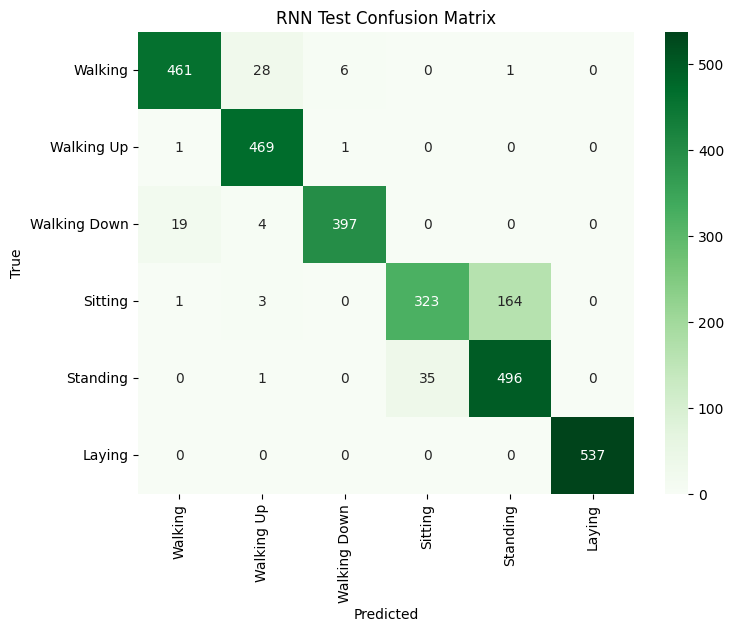

In [37]:
import time
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Test set
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

# loading best model stored
model_rnn.load_state_dict(torch.load('best_rnn_model.pth'))
model_rnn.eval()

test_loss = 0.0
all_preds_test = []
all_labels_test = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_rnn(inputs)

        _, preds = torch.max(outputs, 1)
        all_preds_test.extend(preds.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

activity_names = ['Walking', 'Walking Up', 'Walking Down', 'Sitting', 'Standing', 'Laying']

print("===== Classification Report ====")
print(classification_report(all_labels_test, all_preds_test, target_names=activity_names))

cm_test = confusion_matrix(all_labels_test, all_preds_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=activity_names, yticklabels=activity_names)
plt.title('RNN Test Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

Overall, the sequence model generalizes very well to test sets, achieving a 91% macro-F1 score. The primary cause of error is the confusion between "Sitting" and "Standing". This confusion is highly plausible because both are stationary postures with same gravity. Similarly, model also misclassifies "Walking Down" and "Walking Up", they're barely same posture and model is hard to tell the difference due to shor temperal window.

### Task 14

In [39]:
model_cpu = model_rnn.to('cpu')
model_cpu.eval()

def predict_activity(window_data):
    window_tensor = torch.tensor(window_data, dtype=torch.float32)

    # Add 1 batching from shape (128, 9) to (1, 128, 9)
    window_tensor = window_tensor.unsqueeze(0)

    with torch.no_grad():
        logits = model_cpu(window_tensor)
        probs = F.softmax(logits, dim=1).squeeze().numpy()
        pred_label = np.argmax(probs)

    return int(pred_label), probs

# Measuring for 500 windows
num_samples = 500
latencies = []


for i in range(num_samples):
    sample_window = X_test[i]

    start_time = time.perf_counter()
    label, probs = predict_activity(sample_window)
    end_time = time.perf_counter()

    # We're converting to ms
    latencies.append((end_time - start_time) * 1000)

avg_latency = np.mean(latencies)
p99_latency = np.percentile(latencies, 99)

print(f"Average Latency: {avg_latency:.2f} ms/window")
print(f"P99 Latency: {p99_latency:.2f} ms/window")

Average Latency: 4.40 ms/window
P99 Latency: 4.62 ms/window
